In [1]:
from ax import Client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Dataset in Experiment
# Prior = [0,7]
# MIP = [8,23]
# qLNEI_UCS = [24,39]
# qLNEI_YM = [40,55]

Expt_obj = Client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/ExperimentalSeries-2_TOoUPRCS/Method20250625Dim3_CurSys_qLNEI_UCSvYM/AxExperiment.json")
Expt_df = Expt_obj.summarize()
Expt_obj.get_next_trials(max_trials=1)

{71: {'x1': 0.6181532739894218, 'x2': 0.48721276606237574, 'x3': 0.5}}

# Data Carpentry

In [3]:
Prior_QR_Naive_x1_arr = np.array(Expt_df["x1"][0:8])
Prior_QR_Naive_x2_arr = np.array(Expt_df["x2"][0:8])
Prior_QR_Naive_x3_arr = np.array(Expt_df["x3"][0:8])
Prior_QR_Naive_y1_arr = np.array(Expt_df["ucs"][0:8])
Prior_QR_Naive_y2_arr = np.array(Expt_df["ym"][0:8])

Sequential_MIP_Naive_x1_arr = np.array(Expt_df["x1"][8:24])
Sequential_MIP_Naive_x2_arr = np.array(Expt_df["x2"][8:24])
Sequential_MIP_Naive_x3_arr = np.array(Expt_df["x3"][8:24])
Sequential_MIP_Naive_y1_arr = np.array(Expt_df["ucs"][8:24])
Sequential_MIP_Naive_y2_arr = np.array(Expt_df["ym"][8:24])

Sequential_qLNEI_UCS_x1_arr = np.array(Expt_df["x1"][24:40])
Sequential_qLNEI_UCS_x2_arr = np.array(Expt_df["x2"][24:40])
Sequential_qLNEI_UCS_x3_arr = np.array(Expt_df["x3"][24:40])
Sequential_qLNEI_UCS_y1_arr = np.array(Expt_df["ucs"][24:40])
Sequential_qLNEI_UCS_y2_arr = np.array(Expt_df["ym"][24:40])

Sequential_qLNEI_YM_x1_arr = np.array(Expt_df["x1"][40:56])
Sequential_qLNEI_YM_x2_arr = np.array(Expt_df["x2"][40:56])
Sequential_qLNEI_YM_x3_arr = np.array(Expt_df["x3"][40:56])
Sequential_qLNEI_YM_y1_arr = np.array(Expt_df["ucs"][40:56])
Sequential_qLNEI_YM_y2_arr = np.array(Expt_df["ym"][40:56])

Sequential_qLNEHVI_UCSvsYM_x1_arr = np.array(Expt_df["x1"][55:71])
Sequential_qLNEHVI_UCSvsYM_x2_arr = np.array(Expt_df["x2"][55:71])
Sequential_qLNEHVI_UCSvsYM_x3_arr = np.array(Expt_df["x3"][55:71])
Sequential_qLNEHVI_UCSvsYM_y1_arr = np.array(Expt_df["ucs"][55:71])
Sequential_qLNEHVI_UCSvsYM_y2_arr = np.array(Expt_df["ym"][55:71])

In [4]:
Prior_QR_Naive_X_mat = np.array([Prior_QR_Naive_x1_arr,Prior_QR_Naive_x2_arr,Prior_QR_Naive_x3_arr])
Prior_QR_Naive_Y_mat = np.array([Prior_QR_Naive_y1_arr,Prior_QR_Naive_y2_arr])

Sequential_MIP_Naive_X_mat = np.array([Sequential_MIP_Naive_x1_arr,Sequential_MIP_Naive_x2_arr,Sequential_MIP_Naive_x3_arr])
Sequential_MIP_Naive_Y_mat = np.array([Sequential_MIP_Naive_y1_arr,Sequential_MIP_Naive_y2_arr])

Sequential_qLNEI_UCS_X_mat = np.array([Sequential_qLNEI_UCS_x1_arr,Sequential_qLNEI_UCS_x2_arr,Sequential_qLNEI_UCS_x3_arr])
Sequential_qLNEI_UCS_Y_mat = np.array([Sequential_qLNEI_UCS_y1_arr,Sequential_qLNEI_UCS_y2_arr])

Sequential_qLNEI_YM_X_mat = np.array([Sequential_qLNEI_YM_x1_arr,Sequential_qLNEI_YM_x2_arr,Sequential_qLNEI_YM_x3_arr])
Sequential_qLNEI_YM_Y_mat = np.array([Sequential_qLNEI_YM_y1_arr,Sequential_qLNEI_YM_y2_arr])

Sequential_qLNEHVI_UCSvsYM_X_mat = np.array([Sequential_qLNEHVI_UCSvsYM_x1_arr,Sequential_qLNEHVI_UCSvsYM_x2_arr,Sequential_qLNEHVI_UCSvsYM_x3_arr])
Sequential_qLNEHVI_UCSvsYM_Y_mat = np.array([Sequential_qLNEHVI_UCSvsYM_y1_arr,Sequential_qLNEHVI_UCSvsYM_y2_arr])

In [5]:
Full_UCSvsYM_X_mat = np.concatenate((Prior_QR_Naive_X_mat,Sequential_MIP_Naive_X_mat,Sequential_qLNEI_UCS_X_mat,Sequential_qLNEI_YM_X_mat,Sequential_qLNEHVI_UCSvsYM_X_mat),axis=1)
Full_UCSvsYM_Y_mat = np.concatenate((Prior_QR_Naive_Y_mat,Sequential_MIP_Naive_Y_mat,Sequential_qLNEI_UCS_Y_mat,Sequential_qLNEI_YM_Y_mat,Sequential_qLNEHVI_UCSvsYM_Y_mat),axis=1)
Full_XY_mat = np.concatenate((Full_UCSvsYM_X_mat,Full_UCSvsYM_Y_mat),axis=0)

# Calculations: Mono-Objective Progression by Maximum

In [141]:
# Benchmark Yield Strength Progression
Sequential_MIP_UCS_Progression_ȳ_arr = np.empty(0)
Incumbent_flt = np.max(Prior_QR_Naive_Y_mat[0])
Sequential_MIP_UCS_Progression_ȳ_arr = np.insert(Sequential_MIP_UCS_Progression_ȳ_arr,0,Incumbent_flt)
for ucs in Sequential_MIP_Naive_Y_mat[0]:
    if ucs > Incumbent_flt:
        Incumbent_flt = ucs
    Sequential_MIP_UCS_Progression_ȳ_arr = np.append(Sequential_MIP_UCS_Progression_ȳ_arr,Incumbent_flt)

In [142]:
# Benchmark YM Progression
Sequential_MIP_YM_Progression_ȳ_arr = np.empty(0)
Incumbent_flt = np.max(Prior_QR_Naive_Y_mat[1])
Sequential_MIP_YM_Progression_ȳ_arr = np.insert(Sequential_MIP_YM_Progression_ȳ_arr,0,Incumbent_flt)
for ucs in Sequential_MIP_Naive_Y_mat[1]:
    if ucs > Incumbent_flt:
        Incumbent_flt = ucs
    Sequential_MIP_YM_Progression_ȳ_arr = np.append(Sequential_MIP_YM_Progression_ȳ_arr,Incumbent_flt)

In [143]:
# Sequential Yield Strength Progression
Sequential_qLNEI_UCS_Progression_ȳ_arr = np.empty(0)
Incumbent_flt = np.max(Prior_QR_Naive_Y_mat[0])
Sequential_qLNEI_UCS_Progression_ȳ_arr = np.insert(Sequential_qLNEI_UCS_Progression_ȳ_arr,0,Incumbent_flt)
for ucs in Sequential_qLNEI_UCS_Y_mat[0]:
    if ucs > Incumbent_flt:
        Incumbent_flt = ucs
    Sequential_qLNEI_UCS_Progression_ȳ_arr = np.append(Sequential_qLNEI_UCS_Progression_ȳ_arr,Incumbent_flt)

In [144]:
# Sequential YM Progression
Sequential_qLNEI_YM_Progression_ȳ_arr = np.empty(0)
Incumbent_flt = np.max(Prior_QR_Naive_Y_mat[1])
Sequential_qLNEI_YM_Progression_ȳ_arr = np.insert(Sequential_qLNEI_YM_Progression_ȳ_arr,0,Incumbent_flt)
for ucs in Sequential_qLNEI_YM_Y_mat[1]:
    if ucs > Incumbent_flt:
        Incumbent_flt = ucs
    Sequential_qLNEI_YM_Progression_ȳ_arr = np.append(Sequential_qLNEI_YM_Progression_ȳ_arr,Incumbent_flt)

# Calculations: Mono-Objective Progression by Mean

In [145]:
# Benchmark Yield Strength Progression
Sequential_MIP_UCS_MeanProgression_ȳ_arr = np.empty(0)
IncumbentDataset = Prior_QR_Naive_Y_mat[0]
InitialBenchmarkYieldStrengthMean = np.mean(IncumbentDataset)
for ucs in Sequential_MIP_Naive_Y_mat[0]:
    IncumbentDataset = np.append(IncumbentDataset,ucs)
    Sequential_MIP_UCS_MeanProgression_ȳ_arr = np.append(Sequential_MIP_UCS_MeanProgression_ȳ_arr,np.mean(IncumbentDataset))
Sequential_MIP_UCS_MeanProgression_ȳ_arr = np.insert(Sequential_MIP_UCS_MeanProgression_ȳ_arr,0,InitialBenchmarkYieldStrengthMean)

In [146]:
# Benchmark Young's Modulus Progression
Sequential_MIP_YM_MeanProgression_ȳ_arr = np.empty(0)
IncumbentDataset = Prior_QR_Naive_Y_mat[1]
InitialBenchmarkYoungsModulusMean = np.mean(IncumbentDataset)
for ucs in Sequential_MIP_Naive_Y_mat[1]:
    IncumbentDataset = np.append(IncumbentDataset,ucs)
    Sequential_MIP_YM_MeanProgression_ȳ_arr = np.append(Sequential_MIP_YM_MeanProgression_ȳ_arr,np.mean(IncumbentDataset))
Sequential_MIP_YM_MeanProgression_ȳ_arr = np.insert(Sequential_MIP_YM_MeanProgression_ȳ_arr,0,InitialBenchmarkYoungsModulusMean)

In [147]:
# Sequential Yield Strength Progression
Sequential_qLNEI_UCS_MeanProgression_ȳ_arr = np.empty(0)
IncumbentDataset = Prior_QR_Naive_Y_mat[0]
InitialBenchmarkYieldStrengthMean = np.mean(IncumbentDataset)
for ucs in Sequential_qLNEI_UCS_Y_mat[0]:
    IncumbentDataset = np.append(IncumbentDataset,ucs)
    Sequential_qLNEI_UCS_MeanProgression_ȳ_arr = np.append(Sequential_qLNEI_UCS_MeanProgression_ȳ_arr,np.mean(IncumbentDataset))
Sequential_qLNEI_UCS_MeanProgression_ȳ_arr = np.insert(Sequential_qLNEI_UCS_MeanProgression_ȳ_arr,0,InitialBenchmarkYieldStrengthMean)

In [148]:
# Sequential Young's Modulus Progression
Sequential_qLNEI_YM_MeanProgression_ȳ_arr = np.empty(0)
IncumbentDataset = Prior_QR_Naive_Y_mat[1]
InitialBenchmarkYoungsModulusMean = np.mean(IncumbentDataset)
for ucs in Sequential_qLNEI_YM_Y_mat[1]:
    IncumbentDataset = np.append(IncumbentDataset,ucs)
    Sequential_qLNEI_YM_MeanProgression_ȳ_arr = np.append(Sequential_qLNEI_YM_MeanProgression_ȳ_arr,np.mean(IncumbentDataset))
Sequential_qLNEI_YM_MeanProgression_ȳ_arr = np.insert(Sequential_qLNEI_YM_MeanProgression_ȳ_arr,0,InitialBenchmarkYoungsModulusMean)

# Mono-Objective Optimisation Progressions

In [149]:
Prior_Indices_arr = np.linspace(1,8,8)
Sequential_Indices_arr = np.linspace(9,24,16)
Sequential_Mean_Indices_arr = np.linspace(8,24,17)

In [ ]:
Prior_Color = "#6c757d"
MIP_Color = "#f77f00"
qLNEI_UCS_Color = "#fcbf49"
qLNEI_YM_Color = "#d62828"
qLNEHVI_UCSvsYM_Color = "#0077b6"

In [580]:
Sequential_qLNEI_UCS_Progression_ȳ_arr

array([137.14711422, 137.14711422, 137.14711422, 137.14711422,
       137.14711422, 137.14711422, 137.14711422, 137.14711422,
       137.14711422, 137.17895815, 139.78663519, 139.78663519,
       139.78663519, 143.89399467, 143.89399467, 143.89399467,
       143.89399467])

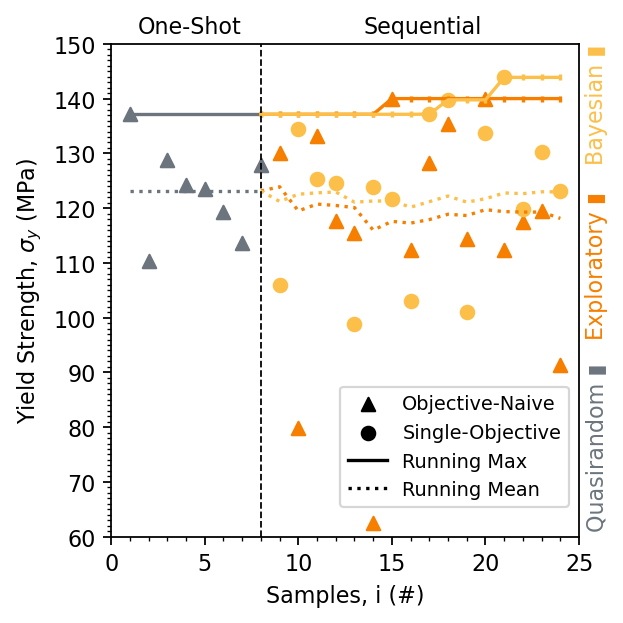

In [591]:
fig, ax1 = plt.subplots(figsize=(4, 4),dpi=160)

# Points
ax1.scatter(Prior_Indices_arr,Prior_QR_Naive_Y_mat[0],marker="^",color=Prior_Color)
ax1.scatter(Sequential_Indices_arr,Sequential_MIP_Naive_Y_mat[0],marker="^",color=MIP_Color)
ax1.scatter(Sequential_Indices_arr,Sequential_qLNEI_UCS_Y_mat[0],color=qLNEI_UCS_Color)

# Maximum Progression
ax1.hlines(y=np.max(Prior_QR_Naive_Y_mat[0]),xmin=1,xmax=8,color=Prior_Color)
ax1.plot(Sequential_Mean_Indices_arr,Sequential_MIP_UCS_Progression_ȳ_arr,color=MIP_Color)
ax1.scatter(Sequential_Mean_Indices_arr,Sequential_MIP_UCS_Progression_ȳ_arr,color=MIP_Color,marker="|",s=8)
ax1.plot(Sequential_Mean_Indices_arr,Sequential_qLNEI_UCS_Progression_ȳ_arr,color=qLNEI_UCS_Color)
ax1.scatter(Sequential_Mean_Indices_arr,Sequential_qLNEI_UCS_Progression_ȳ_arr,color=qLNEI_UCS_Color,marker="|",s=8)

# Mean Progression
ax1.hlines(y=InitialBenchmarkYieldStrengthMean,xmin=1,xmax=8,color=Prior_Color,linestyles="dotted")
ax1.plot(Sequential_Mean_Indices_arr,Sequential_MIP_UCS_MeanProgression_ȳ_arr,color=MIP_Color,linestyle="dotted")
ax1.plot(Sequential_Mean_Indices_arr,Sequential_qLNEI_UCS_MeanProgression_ȳ_arr,color=qLNEI_UCS_Color,linestyle="dotted")

# Axes
ax1.set_ylabel(r"Yield Strength, $\sigma_{y}$ (MPa)")
ax1.set_xlabel("Samples, i (#)")

# Axes' Ticks
xlim=[0,25]
ylim=[60,150]
ax1.set_xlim(xlim[0],xlim[1])
ax1.set_ylim(ylim[0],ylim[1])
ax1.set_xticks(np.linspace(xlim[0],xlim[1],5+1))
ax1.set_yticks(np.linspace(ylim[0],ylim[1],9+1))
ax1.set_xticks(np.linspace(xlim[0],xlim[1],25+1),minor=True)
ax1.set_yticks(np.linspace(ylim[0],ylim[1],90+1),minor=True)

# One-Shot vs Sequential Split
ax1.vlines(x=8,ymin=ylim[0],ymax=ylim[1],color="black",linestyle="dashed",linewidth=0.8)
ax1.text(x=1.4,y=152,s="One-Shot")
ax1.text(x=13.5,y=152,s="Sequential")

# Marking Up
ax1.scatter(100000,100000,marker="^",color="black",label="Objective-Naive")
ax1.scatter(100000,100000,marker="o",color="black",label="Single-Objective")
ax1.plot([100000001,100000002],[100000001,100000002],color="black",label="Running Max")
ax1.plot([100000001,100000002],[100000001,100000002],linestyle="dotted",color="black",label="Running Mean")
ax1.text(x=25.3,y=62,s="Quasirandom ▮",color=Prior_Color,rotation="vertical")
ax1.text(x=25.3,y=97,s="Exploratory ▮",color=MIP_Color,rotation="vertical")
ax1.text(x=25.3,y=129,s="Bayesian ▮",color=qLNEI_UCS_Color,rotation="vertical")

ax1.legend(fontsize=8.7,loc=[0.49,0.06])

fig.tight_layout()
plt.savefig("SOBO-YS-Progression")

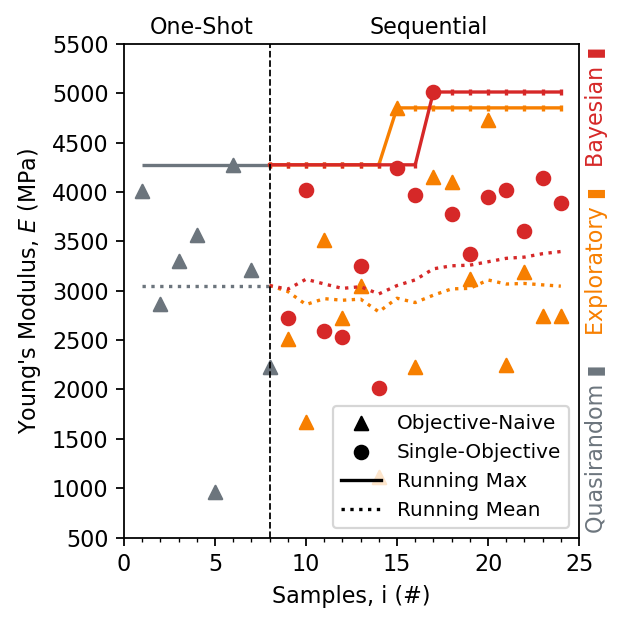

In [592]:
fig, ax1 = plt.subplots(figsize=(4, 4),dpi=160)

# Points
ax1.scatter(Prior_Indices_arr,Prior_QR_Naive_Y_mat[1],marker="^",color=Prior_Color)
ax1.scatter(Sequential_Indices_arr,Sequential_MIP_Naive_Y_mat[1],marker="^",color=MIP_Color)
ax1.scatter(Sequential_Indices_arr,Sequential_qLNEI_YM_Y_mat[1],color=qLNEI_YM_Color)

# Maximum Progression
ax1.hlines(y=np.max(Prior_QR_Naive_Y_mat[1]),xmin=1,xmax=8,color=Prior_Color)
ax1.plot(Sequential_Mean_Indices_arr,Sequential_MIP_YM_Progression_ȳ_arr,color=MIP_Color)
ax1.scatter(Sequential_Mean_Indices_arr,Sequential_MIP_YM_Progression_ȳ_arr,color=MIP_Color,marker="|",s=8)
ax1.plot(Sequential_Mean_Indices_arr,Sequential_qLNEI_YM_Progression_ȳ_arr,color=qLNEI_YM_Color)
ax1.scatter(Sequential_Mean_Indices_arr,Sequential_qLNEI_YM_Progression_ȳ_arr,color=qLNEI_YM_Color,marker="|",s=8)

# Mean Progression
ax1.hlines(y=InitialBenchmarkYoungsModulusMean,xmin=1,xmax=8,color=Prior_Color,linestyles="dotted")
ax1.plot(Sequential_Mean_Indices_arr,Sequential_MIP_YM_MeanProgression_ȳ_arr,color=MIP_Color,linestyle="dotted")
ax1.plot(Sequential_Mean_Indices_arr,Sequential_qLNEI_YM_MeanProgression_ȳ_arr,color=qLNEI_YM_Color,linestyle="dotted")

# Axes
ax1.set_ylabel(r"Young's Modulus, $E$ (MPa)")
ax1.set_xlabel("Samples, i (#)")

# Axes' Ticks
xlim=[0,25]
ylim=[500,5500]
ax1.set_xlim(xlim[0],xlim[1])
ax1.set_ylim(ylim[0],ylim[1])
ax1.set_xticks(np.linspace(xlim[0],xlim[1],5+1))
ax1.set_yticks(np.linspace(ylim[0],ylim[1],10+1))
ax1.set_xticks(np.linspace(xlim[0],xlim[1],25+1),minor=True)

# One-Shot vs Sequential Split
ax1.vlines(x=8,ymin=ylim[0],ymax=ylim[1],color="black",linestyle="dashed",linewidth=0.8)
ax1.text(x=1.4,y=5600,s="One-Shot")
ax1.text(x=13.5,y=5600,s="Sequential")

# Marking Up
ax1.scatter(100000,100000,marker="^",color="black",label="Objective-Naive")
ax1.scatter(100000,100000,marker="o",color="black",label="Single-Objective")
ax1.plot([100000001,100000002],[100000001,100000002],color="black",label="Running Max")
ax1.plot([100000001,100000002],[100000001,100000002],linestyle="dotted",color="black",label="Running Mean")
ax1.text(x=25.3,y=600,s="Quasirandom ▮",color=Prior_Color,rotation="vertical")
ax1.text(x=25.3,y=2600,s="Exploratory ▮",color=MIP_Color,rotation="vertical")
ax1.text(x=25.3,y=4300,s="Bayesian ▮",color=qLNEI_YM_Color,rotation="vertical")

plt.legend(fontsize=9,loc="lower right")

fig.tight_layout()
plt.savefig("SOBO-YM-Progression")

# Dual-Objective Optimisation

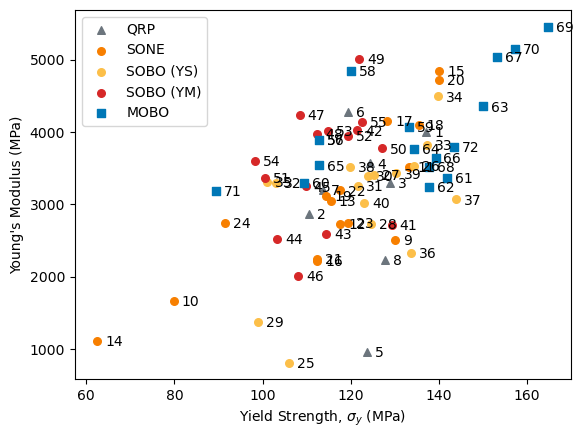

In [316]:
# Overview Plot

plt.scatter(Prior_QR_Naive_Y_mat[0],Prior_QR_Naive_Y_mat[1],color=Prior_Color,label="QRP",s=30,marker="^",alpha=1,zorder=1)
plt.scatter(Sequential_MIP_Naive_Y_mat[0],Sequential_MIP_Naive_Y_mat[1],color=MIP_Color,label="SONE",s=30,alpha=1,zorder=1)
plt.scatter(Sequential_qLNEI_UCS_Y_mat[0],Sequential_qLNEI_UCS_Y_mat[1],color=qLNEI_UCS_Color,label="SOBO (YS)",s=30,alpha=1,zorder=1)
plt.scatter(Sequential_qLNEI_YM_Y_mat[0],Sequential_qLNEI_YM_Y_mat[1],color=qLNEI_YM_Color,label="SOBO (YM)",s=30,alpha=1,zorder=1)

plt.scatter(Sequential_qLNEHVI_UCSvsYM_Y_mat[0],Sequential_qLNEHVI_UCSvsYM_Y_mat[1],color=qLNEHVI_UCSvsYM_Color,label="MOBO",s=30,marker="s",zorder=2)

for counter,row in enumerate(Full_UCSvsYM_Y_mat.T,start=1):
    plt.text(x=row[0]+1.8,y=row[1]-70,s=f"{counter}")

plt.xlabel(r"Yield Strength, $\sigma_{y}$ (MPa)")
plt.ylabel("Young's Modulus (MPa)")

plt.legend()

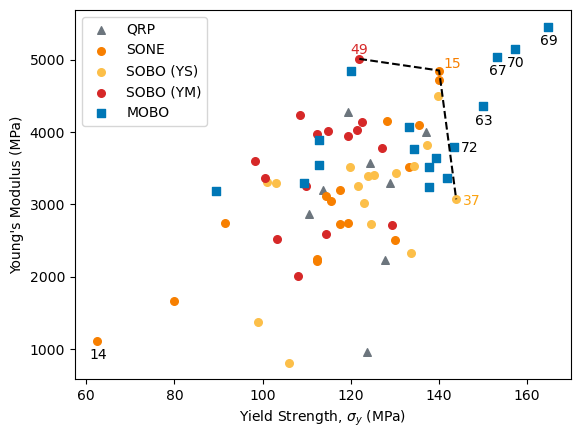

In [317]:
# Sampling Techniques:
# QRP - Quasirandom Prior
# SONE - Single-Objective Naive Exploration
# SOBO - Single-Objective Bayesian Optimisation
# MOBO - Multi-Objective Bayesian Optimisation

# plt.gcf().set_size_inches(10, 4)

plt.scatter(Prior_QR_Naive_Y_mat[0],Prior_QR_Naive_Y_mat[1],color=Prior_Color,label="QRP",s=30,marker="^",alpha=1,zorder=1)
plt.scatter(Sequential_MIP_Naive_Y_mat[0],Sequential_MIP_Naive_Y_mat[1],color=MIP_Color,label="SONE",s=30,alpha=1,zorder=1)
plt.scatter(Sequential_qLNEI_UCS_Y_mat[0],Sequential_qLNEI_UCS_Y_mat[1],color=qLNEI_UCS_Color,label="SOBO (YS)",s=30,alpha=1,zorder=1)
plt.scatter(Sequential_qLNEI_YM_Y_mat[0],Sequential_qLNEI_YM_Y_mat[1],color=qLNEI_YM_Color,label="SOBO (YM)",s=30,alpha=1,zorder=1)

plt.scatter(Sequential_qLNEHVI_UCSvsYM_Y_mat[0],Sequential_qLNEHVI_UCSvsYM_Y_mat[1],color=qLNEHVI_UCSvsYM_Color,label="MOBO",s=30,marker="s",zorder=2)

# for counter,row in enumerate(Sequential_qLNEHVI_UCSvsYM_Y_mat.T,start=57):
#     # plt.text(x=row[0]-5.5,y=row[1]-70,s=f"{counter}",color="black")
#     plt.text(x=row[0]+2.5,y=row[1]-70,s=f"{counter}",color="black")

plt.text(x=Full_UCSvsYM_Y_mat[0][48]-2,y=Full_UCSvsYM_Y_mat[1][48]+75,s="49",color=qLNEI_YM_Color)
plt.text(x=Full_UCSvsYM_Y_mat[0][14]+1,y=Full_UCSvsYM_Y_mat[1][14]+40,s="15",color=MIP_Color)
plt.text(x=Full_UCSvsYM_Y_mat[0][36]+1.5,y=Full_UCSvsYM_Y_mat[1][36]-70,s="37",color="#fca311")

plt.text(x=Full_UCSvsYM_Y_mat[0][68]-1.8,y=Full_UCSvsYM_Y_mat[1][68]-250,s="69",color="black")
plt.text(x=Full_UCSvsYM_Y_mat[0][69]-1.8,y=Full_UCSvsYM_Y_mat[1][69]-250,s="70",color="black")
plt.text(x=Full_UCSvsYM_Y_mat[0][66]-1.8,y=Full_UCSvsYM_Y_mat[1][66]-250,s="67",color="black")
plt.text(x=Full_UCSvsYM_Y_mat[0][62]-1.8,y=Full_UCSvsYM_Y_mat[1][62]-250,s="63",color="black")
plt.text(x=Full_UCSvsYM_Y_mat[0][71]+1.5,y=Full_UCSvsYM_Y_mat[1][71]-70,s="72",color="black")

plt.text(x=Full_UCSvsYM_Y_mat[0][13]-1.8,y=Full_UCSvsYM_Y_mat[1][13]-250,s="14",color="black")

OriginalParetoFront = np.array([[Full_UCSvsYM_Y_mat[0][48],Full_UCSvsYM_Y_mat[0][14],Full_UCSvsYM_Y_mat[0][36]],[Full_UCSvsYM_Y_mat[1][48],Full_UCSvsYM_Y_mat[1][14],Full_UCSvsYM_Y_mat[1][36]]])

plt.plot(OriginalParetoFront[0],OriginalParetoFront[1],color="black",linestyle="dashed")

plt.xlabel(r"Yield Strength, $\sigma_{y}$ (MPa)")
plt.ylabel("Young's Modulus (MPa)")

plt.legend()

In [308]:
Predicted_Y_lis = []
for row in Full_UCSvsYM_X_mat.T:
    PredictedCI_UCS = Expt_obj.predict(points=[{"x1":row[0],"x2":row[1],"x3":row[2]}])[0]["ucs"][1]**0.5
    PredictedCI_YM = Expt_obj.predict(points=[{"x1":row[0],"x2":row[1],"x3":row[2]}])[0]["ym"][1]**0.5
    PredictedCI_UCSvYM_arr = np.array([PredictedCI_UCS,PredictedCI_YM])
    Predicted_Y_lis.append([PredictedCI_UCS,PredictedCI_YM])
PredictedCIY = np.array(Predicted_Y_lis)

Prior_QR_Naive_YVarPred_standardDev_mat = PredictedCIY[0:8]
Sequential_MIP_Naive_YVarPred_standardDev_mat = PredictedCIY[8:24]
Sequential_qLNEI_UCS_YVarPred_standardDev_mat = PredictedCIY[24:40]
Sequential_qLNEI_YM_YVarPred_standardDev_mat = PredictedCIY[40:56]
Sequential_qLNEHVI_UCSvsYM_YVarPred_standardDev_mat = PredictedCIY[55:71]

In [309]:
Prior_QR_Naive_YVarPred_95pctCI_mat = PredictedCIY[0:8]*1.96
Sequential_MIP_Naive_YVarPred_95pctCI_mat = PredictedCIY[8:24]*1.96
Sequential_qLNEI_UCS_YVarPred_95pctCI_mat = PredictedCIY[24:40]*1.96
Sequential_qLNEI_YM_YVarPred_95pctCI_mat = PredictedCIY[40:56]*1.96
Sequential_qLNEHVI_UCSvsYM_YVarPred_95pctCI_mat = PredictedCIY[55:71]*1.96

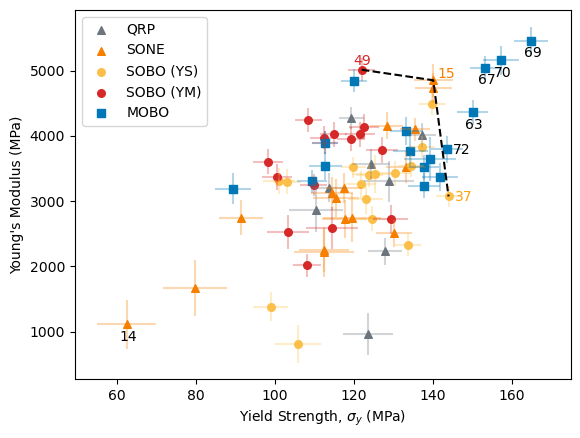

In [310]:
# Sampling Techniques:
# QRP - Quasirandom Prior
# SONE - Single-Objective Naive Exploration
# SOBO - Single-Objective Bayesian Optimisation
# MOBO - Multi-Objective Bayesian Optimisation

# plt.gcf().set_size_inches(10, 4)

# Datapoints
plt.scatter(Prior_QR_Naive_Y_mat[0],Prior_QR_Naive_Y_mat[1],color=Prior_Color,label="QRP",s=30,marker="^",alpha=1,zorder=1)
plt.scatter(Sequential_MIP_Naive_Y_mat[0],Sequential_MIP_Naive_Y_mat[1],color=MIP_Color,label="SONE",s=30,marker="^",alpha=1,zorder=1)
plt.scatter(Sequential_qLNEI_UCS_Y_mat[0],Sequential_qLNEI_UCS_Y_mat[1],color=qLNEI_UCS_Color,label="SOBO (YS)",s=30,alpha=1,zorder=1)
plt.scatter(Sequential_qLNEI_YM_Y_mat[0],Sequential_qLNEI_YM_Y_mat[1],color=qLNEI_YM_Color,label="SOBO (YM)",s=30,alpha=1,zorder=1)
plt.scatter(Sequential_qLNEHVI_UCSvsYM_Y_mat[0],Sequential_qLNEHVI_UCSvsYM_Y_mat[1],color=qLNEHVI_UCSvsYM_Color,label="MOBO",s=30,marker="s",zorder=2)

# 68% CI
plt.errorbar(Prior_QR_Naive_Y_mat[0],Prior_QR_Naive_Y_mat[1],xerr=Prior_QR_Naive_YVarPred_standardDev_mat.T[0],yerr=Prior_QR_Naive_YVarPred_standardDev_mat.T[1],fmt="none",color=Prior_Color,alpha=0.3)
plt.errorbar(Sequential_MIP_Naive_Y_mat[0],Sequential_MIP_Naive_Y_mat[1],xerr=Sequential_MIP_Naive_YVarPred_standardDev_mat.T[0],yerr=Sequential_MIP_Naive_YVarPred_standardDev_mat.T[1],fmt="none",color=MIP_Color,alpha=0.3)
plt.errorbar(Sequential_qLNEI_UCS_Y_mat[0],Sequential_qLNEI_UCS_Y_mat[1],xerr=Sequential_qLNEI_UCS_YVarPred_standardDev_mat.T[0],yerr=Sequential_qLNEI_UCS_YVarPred_standardDev_mat.T[1],fmt="none",color=qLNEI_UCS_Color,alpha=0.3)
plt.errorbar(Sequential_qLNEI_YM_Y_mat[0],Sequential_qLNEI_YM_Y_mat[1],xerr=Sequential_qLNEI_YM_YVarPred_standardDev_mat.T[0],yerr=Sequential_qLNEI_YM_YVarPred_standardDev_mat.T[1],fmt="none",color=qLNEI_YM_Color,alpha=0.3)
plt.errorbar(Sequential_qLNEHVI_UCSvsYM_Y_mat[0],Sequential_qLNEHVI_UCSvsYM_Y_mat[1],xerr=Sequential_qLNEHVI_UCSvsYM_YVarPred_standardDev_mat.T[0],yerr=Sequential_qLNEHVI_UCSvsYM_YVarPred_standardDev_mat.T[1],fmt="none",color=qLNEHVI_UCSvsYM_Color,alpha=0.3)

# 95% CI
# plt.errorbar(Prior_QR_Naive_Y_mat[0],Prior_QR_Naive_Y_mat[1],xerr=Prior_QR_Naive_YVarPred_95pctCI_mat.T[0],yerr=Prior_QR_Naive_YVarPred_95pctCI_mat.T[1],fmt="none",color=Prior_Color,alpha=0.3)
# plt.errorbar(Sequential_MIP_Naive_Y_mat[0],Sequential_MIP_Naive_Y_mat[1],xerr=Sequential_MIP_Naive_YVarPred_95pctCI_mat.T[0],yerr=Sequential_MIP_Naive_YVarPred_95pctCI_mat.T[1],fmt="none",color=MIP_Color,alpha=0.3)
# plt.errorbar(Sequential_qLNEI_UCS_Y_mat[0],Sequential_qLNEI_UCS_Y_mat[1],xerr=Sequential_qLNEI_UCS_YVarPred_95pctCI_mat.T[0],yerr=Sequential_qLNEI_UCS_YVarPred_95pctCI_mat.T[1],fmt="none",color=qLNEI_UCS_Color,alpha=0.3)
# plt.errorbar(Sequential_qLNEI_YM_Y_mat[0],Sequential_qLNEI_YM_Y_mat[1],xerr=Sequential_qLNEI_YM_YVarPred_95pctCI_mat.T[0],yerr=Sequential_qLNEI_YM_YVarPred_95pctCI_mat.T[1],fmt="none",color=qLNEI_YM_Color,alpha=0.3)
# plt.errorbar(Sequential_qLNEHVI_UCSvsYM_Y_mat[0],Sequential_qLNEHVI_UCSvsYM_Y_mat[1],xerr=Sequential_qLNEHVI_UCSvsYM_YVarPred_95pctCI_mat.T[0],yerr=Sequential_qLNEHVI_UCSvsYM_YVarPred_95pctCI_mat.T[1],fmt="none",color=qLNEHVI_UCSvsYM_Color,alpha=0.3)

# for counter,row in enumerate(Sequential_qLNEHVI_UCSvsYM_Y_mat.T,start=57):
#     # plt.text(x=row[0]-5.5,y=row[1]-70,s=f"{counter}",color="black")
#     plt.text(x=row[0]+2.5,y=row[1]-70,s=f"{counter}",color="black")

plt.text(x=Full_UCSvsYM_Y_mat[0][48]-2,y=Full_UCSvsYM_Y_mat[1][48]+75,s="49",color=qLNEI_YM_Color)
plt.text(x=Full_UCSvsYM_Y_mat[0][14]+1,y=Full_UCSvsYM_Y_mat[1][14]+40,s="15",color=MIP_Color)
plt.text(x=Full_UCSvsYM_Y_mat[0][36]+1.5,y=Full_UCSvsYM_Y_mat[1][36]-70,s="37",color="#fca311")

plt.text(x=Full_UCSvsYM_Y_mat[0][68]-1.8,y=Full_UCSvsYM_Y_mat[1][68]-250,s="69",color="black")
plt.text(x=Full_UCSvsYM_Y_mat[0][69]-1.8,y=Full_UCSvsYM_Y_mat[1][69]-250,s="70",color="black")
plt.text(x=Full_UCSvsYM_Y_mat[0][66]-1.8,y=Full_UCSvsYM_Y_mat[1][66]-250,s="67",color="black")
plt.text(x=Full_UCSvsYM_Y_mat[0][62]-1.8,y=Full_UCSvsYM_Y_mat[1][62]-250,s="63",color="black")
plt.text(x=Full_UCSvsYM_Y_mat[0][71]+1.5,y=Full_UCSvsYM_Y_mat[1][71]-70,s="72",color="black")

plt.text(x=Full_UCSvsYM_Y_mat[0][13]-1.8,y=Full_UCSvsYM_Y_mat[1][13]-250,s="14",color="black")

OriginalParetoFront = np.array([[Full_UCSvsYM_Y_mat[0][48],Full_UCSvsYM_Y_mat[0][14],Full_UCSvsYM_Y_mat[0][36]],[Full_UCSvsYM_Y_mat[1][48],Full_UCSvsYM_Y_mat[1][14],Full_UCSvsYM_Y_mat[1][36]]])

plt.plot(OriginalParetoFront[0],OriginalParetoFront[1],color="black",linestyle="dashed")

plt.xlabel(r"Yield Strength, $\sigma_{y}$ (MPa)")
plt.ylabel("Young's Modulus (MPa)")

plt.legend()

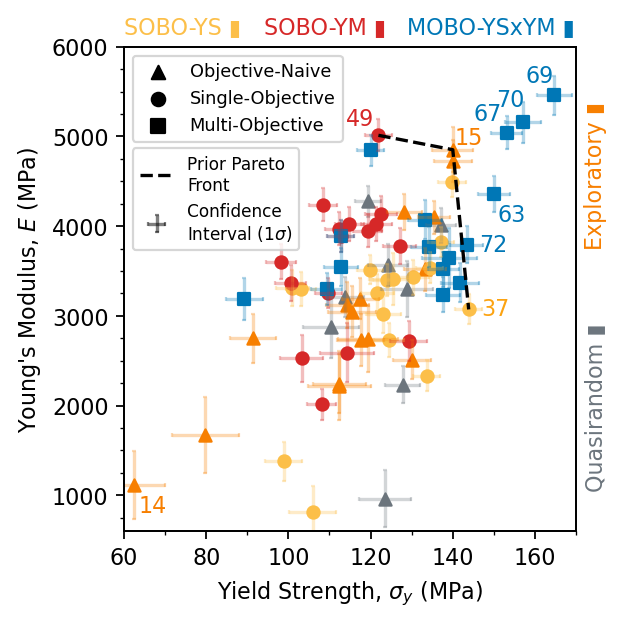

In [561]:
fig, ax1 = plt.subplots(figsize=(4, 4),dpi=160)

# Datapoints
ax1.scatter(Prior_QR_Naive_Y_mat[0],Prior_QR_Naive_Y_mat[1],color=Prior_Color,s=30,marker="^",alpha=1,zorder=1)
ax1.scatter(Sequential_MIP_Naive_Y_mat[0],Sequential_MIP_Naive_Y_mat[1],color=MIP_Color,s=30,marker="^",alpha=1,zorder=1)
ax1.scatter(Sequential_qLNEI_UCS_Y_mat[0],Sequential_qLNEI_UCS_Y_mat[1],color=qLNEI_UCS_Color,s=30,alpha=1,zorder=1)
ax1.scatter(Sequential_qLNEI_YM_Y_mat[0],Sequential_qLNEI_YM_Y_mat[1],color=qLNEI_YM_Color,s=30,alpha=1,zorder=1)
ax1.scatter(Sequential_qLNEHVI_UCSvsYM_Y_mat[0],Sequential_qLNEHVI_UCSvsYM_Y_mat[1],color=qLNEHVI_UCSvsYM_Color,s=30,marker="s",zorder=2)

# 68% CI
ax1.errorbar(Prior_QR_Naive_Y_mat[0],Prior_QR_Naive_Y_mat[1],xerr=Prior_QR_Naive_YVarPred_standardDev_mat.T[0],yerr=Prior_QR_Naive_YVarPred_standardDev_mat.T[1],fmt="none",color=Prior_Color,alpha=0.3,capsize=1)
ax1.errorbar(Sequential_MIP_Naive_Y_mat[0],Sequential_MIP_Naive_Y_mat[1],xerr=Sequential_MIP_Naive_YVarPred_standardDev_mat.T[0],yerr=Sequential_MIP_Naive_YVarPred_standardDev_mat.T[1],fmt="none",color=MIP_Color,alpha=0.3,capsize=1)
ax1.errorbar(Sequential_qLNEI_UCS_Y_mat[0],Sequential_qLNEI_UCS_Y_mat[1],xerr=Sequential_qLNEI_UCS_YVarPred_standardDev_mat.T[0],yerr=Sequential_qLNEI_UCS_YVarPred_standardDev_mat.T[1],fmt="none",color=qLNEI_UCS_Color,alpha=0.3,capsize=1)
ax1.errorbar(Sequential_qLNEI_YM_Y_mat[0],Sequential_qLNEI_YM_Y_mat[1],xerr=Sequential_qLNEI_YM_YVarPred_standardDev_mat.T[0],yerr=Sequential_qLNEI_YM_YVarPred_standardDev_mat.T[1],fmt="none",color=qLNEI_YM_Color,alpha=0.3,capsize=1)
ax1.errorbar(Sequential_qLNEHVI_UCSvsYM_Y_mat[0],Sequential_qLNEHVI_UCSvsYM_Y_mat[1],xerr=Sequential_qLNEHVI_UCSvsYM_YVarPred_standardDev_mat.T[0],yerr=Sequential_qLNEHVI_UCSvsYM_YVarPred_standardDev_mat.T[1],fmt="none",color=qLNEHVI_UCSvsYM_Color,alpha=0.3,capsize=1)

# Numbered Original Pareto Front
ax1.text(x=Full_UCSvsYM_Y_mat[0][48]-8,y=Full_UCSvsYM_Y_mat[1][48]+110,s="49",color=qLNEI_YM_Color)
ax1.text(x=Full_UCSvsYM_Y_mat[0][14]+0.5,y=Full_UCSvsYM_Y_mat[1][14]+60,s="15",color=MIP_Color)
ax1.text(x=Full_UCSvsYM_Y_mat[0][36]+3,y=Full_UCSvsYM_Y_mat[1][36]-70,s="37",color="#fca311")
OriginalParetoFront = np.array([[Full_UCSvsYM_Y_mat[0][48],Full_UCSvsYM_Y_mat[0][14],Full_UCSvsYM_Y_mat[0][36]],[Full_UCSvsYM_Y_mat[1][48],Full_UCSvsYM_Y_mat[1][14],Full_UCSvsYM_Y_mat[1][36]]])
ax1.plot(OriginalParetoFront[0],OriginalParetoFront[1],color="black",linestyle="dashed")

# Numbered MOBO Points
ax1.text(x=Full_UCSvsYM_Y_mat[0][68]-7,y=Full_UCSvsYM_Y_mat[1][68]+150,s="69",color=qLNEHVI_UCSvsYM_Color)
ax1.text(x=Full_UCSvsYM_Y_mat[0][69]-6.5,y=Full_UCSvsYM_Y_mat[1][69]+180,s="70",color=qLNEHVI_UCSvsYM_Color)
ax1.text(x=Full_UCSvsYM_Y_mat[0][66]-8,y=Full_UCSvsYM_Y_mat[1][66]+140,s="67",color=qLNEHVI_UCSvsYM_Color)
ax1.text(x=Full_UCSvsYM_Y_mat[0][62]+1,y=Full_UCSvsYM_Y_mat[1][62]-300,s="63",color=qLNEHVI_UCSvsYM_Color)
ax1.text(x=Full_UCSvsYM_Y_mat[0][71]+3,y=Full_UCSvsYM_Y_mat[1][71]-70,s="72",color=qLNEHVI_UCSvsYM_Color)

# Worst Point
ax1.text(x=Full_UCSvsYM_Y_mat[0][13]+1,y=Full_UCSvsYM_Y_mat[1][13]-300,s="14",color=MIP_Color)

# Axes
ax1.set_xlabel(r"Yield Strength, $\sigma_{y}$ (MPa)")
ax1.set_ylabel(r"Young's Modulus, $E$ (MPa)")

# Axes' Ticks
xlim=[60,170]
ylim=[600,6000]
ax1.set_xticks(np.linspace(0,200,10+1))
ax1.set_xticks(np.linspace(0,200,20+1),minor=True)
ax1.set_yticks(np.linspace(0,6000,6+1))
ax1.set_yticks(np.linspace(0,6000,24+1),minor=True)
ax1.set_xlim(xlim[0],xlim[1])
ax1.set_ylim(ylim[0],ylim[1])

# Marking Up
ax1.scatter(100000,100000,marker="^",color="black",label="Objective-Naive")
ax1.scatter(100000,100000,marker="o",color="black",label="Single-Objective")
ax1.scatter(100000,100000,marker="s",color="black",label="Multi-Objective")
ax1.text(x=172,y=1100,s="Quasirandom ▮",color=Prior_Color,rotation="vertical")
ax1.text(x=172,y=3800,s="Exploratory ▮",color=MIP_Color,rotation="vertical")
ax1.text(x=60,y=6150,s="SOBO-YS ▮",color=qLNEI_UCS_Color,rotation="horizontal")
ax1.text(x=94,y=6150,s="SOBO-YM ▮",color=qLNEI_YM_Color,rotation="horizontal")
ax1.text(x=129,y=6150,s="MOBO-YSxYM ▮",color=qLNEHVI_UCSvsYM_Color,rotation="horizontal")

# ax1.text(x=142,y=1000,s="Prior Pareto Front",rotation=-85,fontsize=9)

ax1.legend(fontsize=8,loc="upper left")

ax2 = ax1.twinx()
# ax2.set_xticks([])
ax2.set_yticks([])
ax2.errorbar([100001],[100002],xerr=[1],yerr=[1],fmt="none",color="black",capsize=1,alpha=0.5,label="Confidence\n"+r"Interval (1$\sigma$)")
ax2.plot([100001,100002],[100001,100002],color="black",linestyle="dashed",label="Prior Pareto\nFront")
# ax2.legend(fontsize=8,loc=[0.6,0.08])
ax2.legend(fontsize=7.6,loc=[0.02,0.58])

fig.tight_layout()
plt.savefig("MOBO-Progression")

# Plotting Marginals of the Gaussian Process at Mean

In [545]:
x1_range_lis = [0.45,1.00] # 45-100% StockUPR1 (55-0% DmI) # x1
x2_range_lis = [0.40,1.00] # 40-100% I1 (60-0% CS)         # x2
x3_range_lis = [0.50,0.95] # 50-95% UPR1 (50-5% I2)        # x3

In [549]:
x1_avg_flt = np.mean(Full_UCSvsYM_X_mat[0])
x2_avg_flt = np.mean(Full_UCSvsYM_X_mat[1])
x3_avg_flt = np.mean(Full_UCSvsYM_X_mat[2])

In [550]:
n = 100
x1_samples = np.linspace(x1_range_lis[0],x1_range_lis[1],n)
x2_samples = np.linspace(x2_range_lis[0],x2_range_lis[1],n)
x3_samples = np.linspace(x3_range_lis[0],x3_range_lis[1],n)

In [551]:
# NOTE: The predict function returns covariance of a point with itself: the variance around a single point in space.
# The 95% confidence interval is therefore equal to (predicted variance ** 0.5) * 1.96
x1_pred_ys_arr = np.empty(0)
x1_var_ys_arr = np.empty(0)
for i in x1_samples:
    x1_pred_ys_arr = np.append(x1_pred_ys_arr,Expt_obj.predict(points=[{"x1":i,"x2":x2_avg_flt,"x3":x3_avg_flt}])[0]["ucs"][0])
    x1_var_ys_arr = np.append(x1_var_ys_arr,Expt_obj.predict(points=[{"x1":i,"x2":x2_avg_flt,"x3":x3_avg_flt}])[0]["ucs"][1]**0.5*1.96)

x2_pred_ys_arr = np.empty(0)
x2_var_ys_arr = np.empty(0)
for i in x2_samples:
    x2_pred_ys_arr = np.append(x2_pred_ys_arr,Expt_obj.predict(points=[{"x1":x1_avg_flt,"x2":i,"x3":x3_avg_flt}])[0]["ucs"][0])
    x2_var_ys_arr = np.append(x2_var_ys_arr,Expt_obj.predict(points=[{"x1":x1_avg_flt,"x2":i,"x3":x3_avg_flt}])[0]["ucs"][1]**0.5*1.96)

x3_pred_ys_arr = np.empty(0)
x3_var_ys_arr = np.empty(0)
for i in x3_samples:
    x3_pred_ys_arr = np.append(x3_pred_ys_arr,Expt_obj.predict(points=[{"x1":x1_avg_flt,"x2":x2_avg_flt,"x3":i}])[0]["ucs"][0])
    x3_var_ys_arr = np.append(x3_var_ys_arr,Expt_obj.predict(points=[{"x1":x1_avg_flt,"x2":x2_avg_flt,"x3":i}])[0]["ucs"][1]**0.5*1.96)

In [552]:
x1_pred_ym_arr = np.empty(0)
x1_var_ym_arr = np.empty(0)
for i in x1_samples:
    x1_pred_ym_arr = np.append(x1_pred_ym_arr,Expt_obj.predict(points=[{"x1":i,"x2":x2_avg_flt,"x3":x3_avg_flt}])[0]["ym"][0])
    x1_var_ym_arr = np.append(x1_var_ym_arr,Expt_obj.predict(points=[{"x1":i,"x2":x2_avg_flt,"x3":x3_avg_flt}])[0]["ym"][1]**0.5*1.96)

x2_pred_ym_arr = np.empty(0)
x2_var_ym_arr = np.empty(0)
for i in x2_samples:
    x2_pred_ym_arr = np.append(x2_pred_ym_arr,Expt_obj.predict(points=[{"x1":x1_avg_flt,"x2":i,"x3":x3_avg_flt}])[0]["ym"][0])
    x2_var_ym_arr = np.append(x2_var_ym_arr,Expt_obj.predict(points=[{"x1":x1_avg_flt,"x2":i,"x3":x3_avg_flt}])[0]["ym"][1]**0.5*1.96)

x3_pred_ym_arr = np.empty(0)
x3_var_ym_arr = np.empty(0)
for i in x3_samples:
    x3_pred_ym_arr = np.append(x3_pred_ym_arr,Expt_obj.predict(points=[{"x1":x1_avg_flt,"x2":x2_avg_flt,"x3":i}])[0]["ym"][0])
    x3_var_ym_arr = np.append(x3_var_ym_arr,Expt_obj.predict(points=[{"x1":x1_avg_flt,"x2":x2_avg_flt,"x3":i}])[0]["ym"][1]**0.5*1.96)

In [553]:
x1_69 = Full_UCSvsYM_X_mat[0][68]
x2_69 = Full_UCSvsYM_X_mat[1][68]
x3_69 = Full_UCSvsYM_X_mat[2][68]

x1_14 = Full_UCSvsYM_X_mat[0][13]
x2_14 = Full_UCSvsYM_X_mat[1][13]
x3_14 = Full_UCSvsYM_X_mat[2][13]

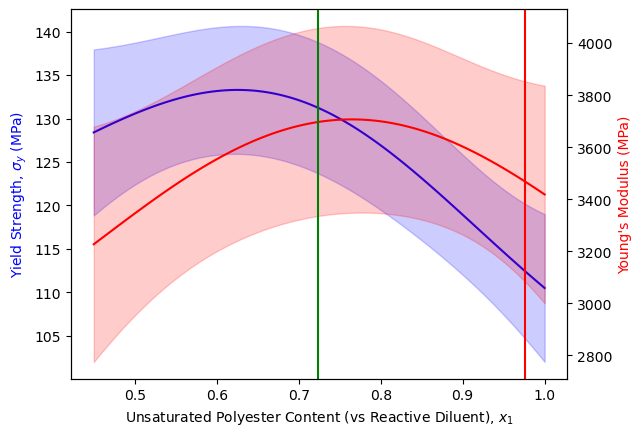

In [554]:
fig, ax1 = plt.subplots()

ax1.plot(x1_samples,x1_pred_ys_arr,color="blue")
ax1.set_ylabel(r"Yield Strength, $\sigma_{y}$ (MPa)",color="blue")
ax1.set_xlabel(r"Unsaturated Polyester Content (vs Reactive Diluent), $x_{1}$")
ax1.fill_between(x=x1_samples,y1=x1_pred_ys_arr-x1_var_ys_arr,y2=x1_pred_ys_arr+x1_var_ys_arr,alpha=0.2,color="blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Young's Modulus (MPa)",color="red")
ax2.plot(x1_samples,x1_pred_ym_arr,color="red")
ax2.fill_between(x=x1_samples,y1=x1_pred_ym_arr-x1_var_ym_arr,y2=x1_pred_ym_arr+x1_var_ym_arr,alpha=0.2,color="red")

ax2.axvline(x=x1_69,color="green")
ax2.axvline(x=x1_14,color="red")

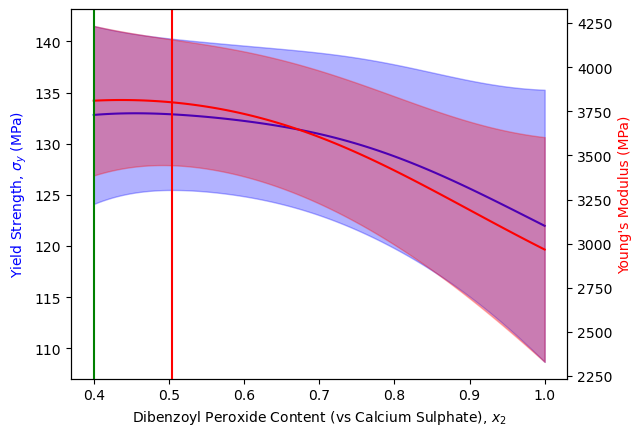

In [555]:
fig, ax1 = plt.subplots()

ax1.plot(x2_samples,x2_pred_ys_arr,color="blue")
ax1.set_ylabel(r"Yield Strength, $\sigma_{y}$ (MPa)",color="blue")
ax1.set_xlabel(r"Dibenzoyl Peroxide Content (vs Calcium Sulphate), $x_{2}$")
ax1.fill_between(x=x2_samples,y1=x2_pred_ys_arr-x2_var_ys_arr,y2=x2_pred_ys_arr+x2_var_ys_arr,alpha=0.3,color="blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Young's Modulus (MPa)",color="red")
ax2.plot(x2_samples,x2_pred_ym_arr,color="red")
ax2.fill_between(x=x2_samples,y1=x2_pred_ym_arr-x2_var_ym_arr,y2=x2_pred_ym_arr+x2_var_ym_arr,alpha=0.3,color="red")

ax2.axvline(x=x2_69,color="green")
ax2.axvline(x=x2_14,color="red")

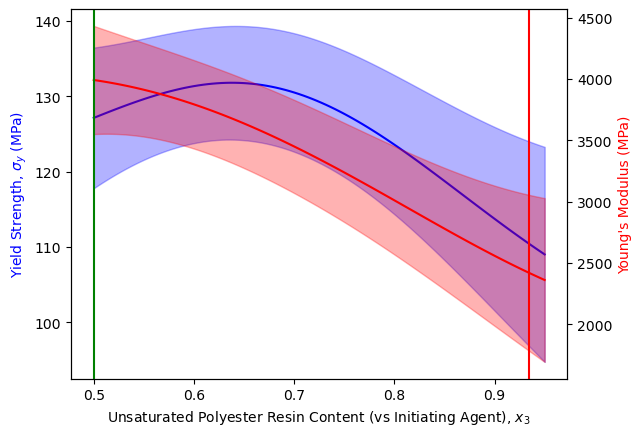

In [556]:
fig, ax1 = plt.subplots()

ax1.plot(x3_samples,x3_pred_ys_arr,color="blue")
ax1.set_ylabel(r"Yield Strength, $\sigma_{y}$ (MPa)",color="blue")
ax1.set_xlabel(r"Unsaturated Polyester Resin Content (vs Initiating Agent), $x_{3}$")
ax1.fill_between(x=x3_samples,y1=x3_pred_ys_arr-x3_var_ys_arr,y2=x3_pred_ys_arr+x3_var_ys_arr,alpha=0.3,color="blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Young's Modulus (MPa)",color="red")
ax2.plot(x3_samples,x3_pred_ym_arr,color="red")
ax2.fill_between(x=x3_samples,y1=x3_pred_ym_arr-x3_var_ym_arr,y2=x3_pred_ym_arr+x3_var_ym_arr,alpha=0.3,color="red")

ax2.axvline(x=x3_69,color="green")
ax2.axvline(x=x3_14,color="red")

# Interative Overview Plots

In [ ]:
plot_mat = np.concatenate((np.expand_dims(np.linspace(1,len(Full_XY_mat.T),len(Full_XY_mat.T)),1).T,Full_XY_mat),axis=0)

In [ ]:
array = plot_mat.T
index_values = np.linspace(0,len(Full_XY_mat[0])-1,len(Full_XY_mat[0]))
column_values = ['sample','x1','x2','x3','y1','y2']
plot_df = pd.DataFrame(data=array,index=index_values,columns=column_values)
plot_df

In [ ]:
import plotly.express as px
fig = px.scatter_3d(plot_df,x='x1',y='x2',z='x3',color='y1',size='sample')
fig.show()

In [ ]:
Expt_obj.compute_analyses()